# Задача регрессии предсказания цены на старый автомобиль

Ссылка на датасет:  
https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset

В датасете содержится 4000 объектов, и 12 признаков, целевая переменная - 'price'

Для начала будет проведен EDA и feature engineering, после чего применены модели машинного обучения: Линейная регрессия, с L1, L2 и ElasticNet регуляризациями, рандомный лес, CatBoost и LightGBM.
    
Также на основе EDA будут выдвинуты гипотезы, которые в дальнейшнем будут проверены и в конце будет дан вывод о них.

# Обзор датасета

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/used_cars.csv')

In [3]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [5]:
df.nunique()

,0
brand,57
model,1898
model_year,34
milage,2818
fuel_type,7
engine,1146
transmission,62
ext_col,319
int_col,156
accident,2


Как видно датасет содержит 11 признаков  
**brand** - марка автомобиля   
**model** - модель  
**model_year** - год выпуска модели  
**milage** - пробег  
**fuel_type** - вид топлива  
**engine** - информация о двигателе  
**transmission** - информация о трансмиссии  
**ext_col** - внешний цвет  
**int_color** - цвет салона  
**accident** - история аварий  
**clean_title** - особый статус  автомобиля, показывает, чист ли он перед страховой компанией  
**price** - целевая переменная, которую будем предсказывать


# Гипотезы

**Выдвенем гипотезы:**


1.   Ожидается, что сильнее всего на стоимость повлияют марка, пробег, двигатель и история аварий
2.   Меньше всего на стоимость будут влиять вид топлива, цвета салона и корпуса, а также информация о трансмиссии  
3.   Линейная регрессия покажет хороший результат, потому что признаки должны линейно влиять на стоимость, кажется, что скрытых зависимостей здесь будет мало
4.  Заполнение пропущенных значений средними даст лучшую точность для случайного леса, чем удаление признаков с пропусками из обучающеЙ выборки



# EDA

Как видно, большинство наших признаков - категориальные  
Исправим это

In [6]:
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [7]:
df['milage'] = (
    df['milage']
    .str.replace(',', '', regex=False)
    .str.replace('mi.', '', regex=False)
    .astype(float)
)

In [8]:
df['engine_volume'] = (
    df['engine']
    .str.extract(r'(\d+(?:\.\d+)?)L')[0]
    .astype(float)
)

In [9]:
df['accidents_num'] = (
    df['accident']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

In [10]:
df['transmission_speed'] = (
    df['transmission']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

In [11]:
df.describe()

,model_year,milage,price,engine_volume,accidents_num,transmission_speed
count,4009.000000,4009.000000,4.009000e+03,3632.000000,986.0,2176.000000
mean,2015.515590,64717.551010,4.455319e+04,3.709045,1.0,6.834099
std,6.104816,52296.599459,7.871064e+04,1.423147,0.0,1.871395
min,1974.000000,100.000000,2.000000e+03,0.650000,1.0,1.000000
25%,2012.000000,23044.000000,1.720000e+04,2.500000,1.0,6.000000
50%,2017.000000,52775.000000,3.100000e+04,3.500000,1.0,7.000000
75%,2020.000000,94100.000000,4.999000e+04,4.700000,1.0,8.000000
max,2024.000000,405000.000000,2.954083e+06,8.400000,1.0,10.000000


Все признаки, из которых можно было достать числовую информацию, были обработаны, теперь можем смотреть на распределения

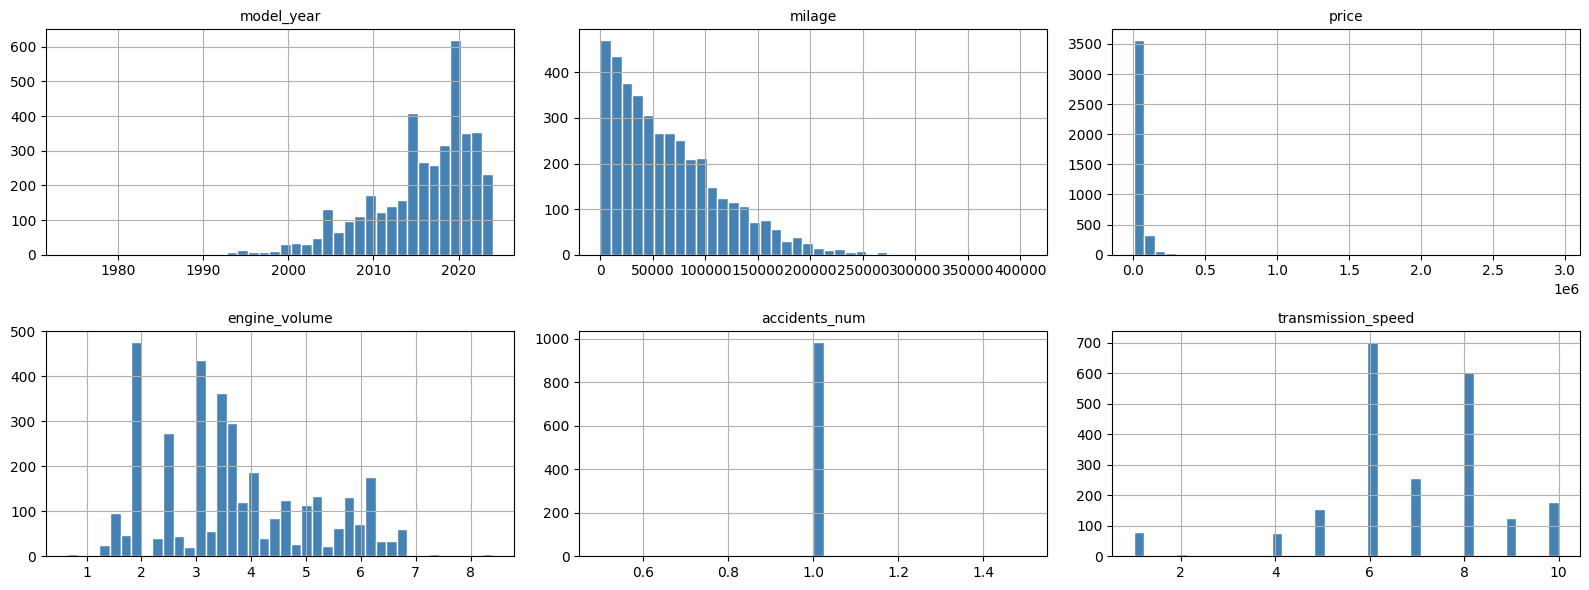

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 3, figsize = (16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
  df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
  axes[i].set_title(col, fontsize = 10)

for j in range(len(numeric_cols), len(axes)):
  axes[j].set_visible(False)

plt.tight_layout()
plt.show()


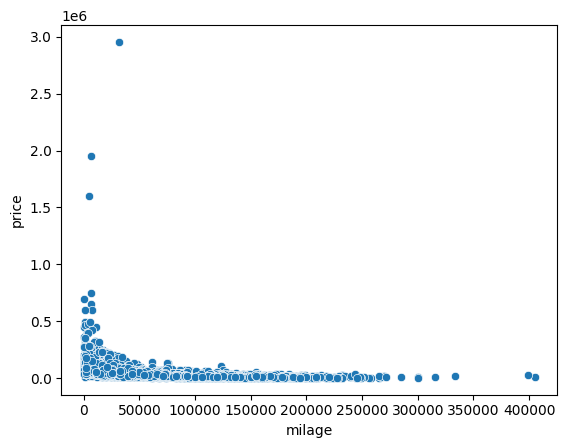

In [13]:
sns.scatterplot(data=df, x='milage', y='price')
plt.show()

Как видим есть 3 выброса с огромной ценой, удалим их

In [14]:
df = df[df['price'] <= 1000000]

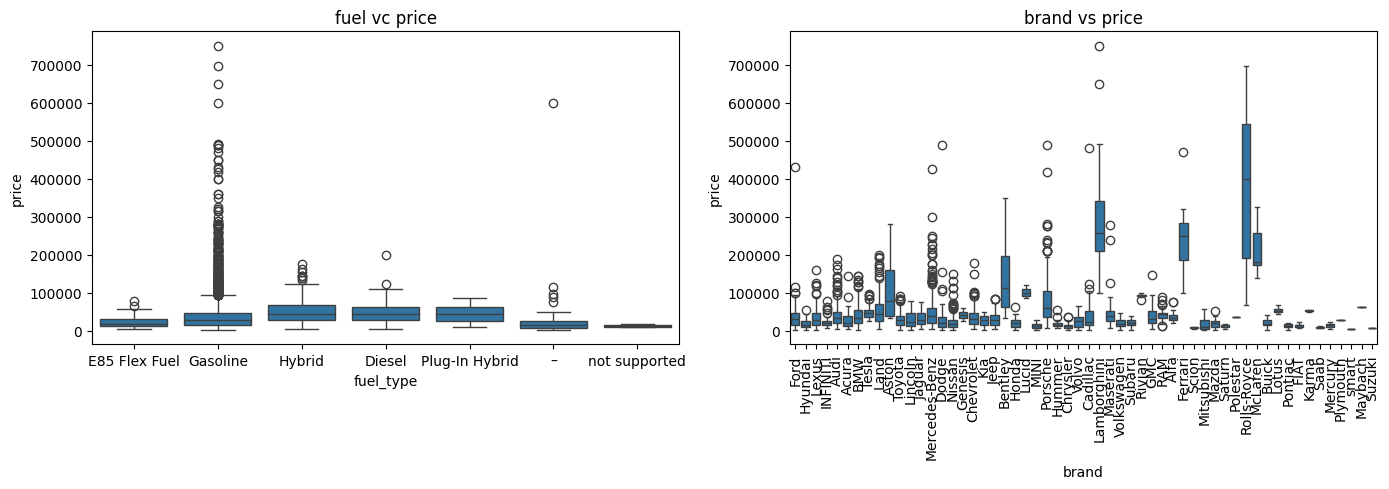

In [15]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

sns.boxplot(data=df, x='fuel_type', y='price', ax = axes[0])
axes[0].set_title('fuel vc price')

sns.boxplot(data=df, x='brand', y='price', ax = axes[1])
axes[1].set_title('brand vs price')
plt.xticks(rotation = 90)

plt.tight_layout()

plt.show()

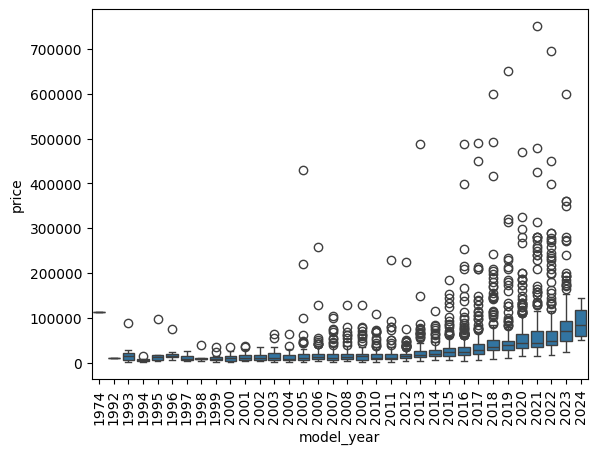

In [16]:
sns.boxplot(data=df, x='model_year', y='price')
plt.xticks(rotation = 90)
plt.show()

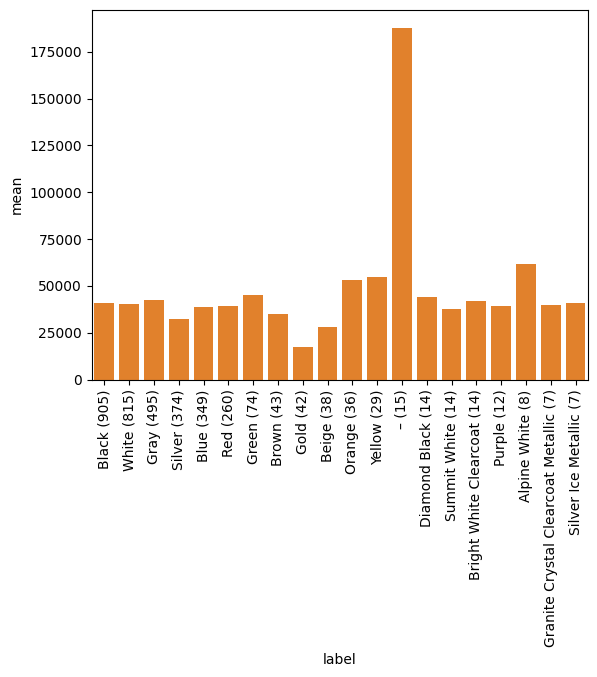

In [17]:
mean_price_ext = (
    df.groupby('ext_col')['price']
    .agg(['mean', 'count'])
    .sort_values('count', ascending=False)
    .head(20)
)

mean_price_ext['label'] = (
    mean_price_ext.index + ' (' +
    mean_price_ext['count'].astype(str) + ')'
)

sns.barplot(
    x=mean_price_ext['label'],
    y=mean_price_ext['mean']
)

sns.barplot(
    x=mean_price_ext['label'],
    y=mean_price_ext['mean']
)

plt.xticks(rotation=90)
plt.show()

Как видно в среднем все одинаково, то есть цвет действительно не влияет на стоимость автомобиля, рассмотрим еще цвет салона

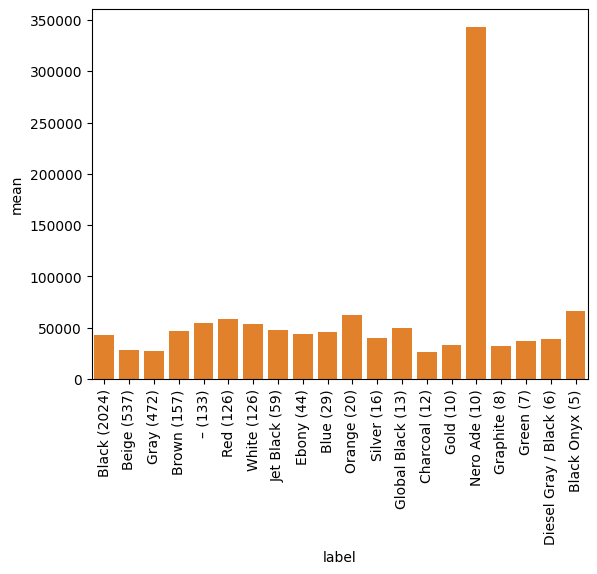

In [18]:
mean_price_int = (
    df.groupby('int_col')['price']
    .agg(['mean', 'count'])
    .sort_values('count', ascending=False)
    .head(20)
)

mean_price_int['label'] = (
    mean_price_int.index + ' (' +
    mean_price_int['count'].astype(str) + ')'
)

sns.barplot(
    x=mean_price_int['label'],
    y=mean_price_int['mean']
)

sns.barplot(
    x=mean_price_int['label'],
    y=mean_price_int['mean']
)

plt.xticks(rotation=90)
plt.show()

In [19]:
df[df['int_col'] == 'Nero Ade']

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,engine_volume,accidents_num,transmission_speed
76,Lamborghini,Huracan Tecnica Coupe,2023,255.0,Gasoline,"5.2L V-10 gasoline direct injection, DOHC, var...",Automatic,BLU ELEOS,Nero Ade,None reported,NaN,359991.0,5.2,NaN,NaN
254,Lamborghini,Huracan Tecnica Coupe,2023,278.0,Gasoline,"5.2L V-10 gasoline direct injection, DOHC, var...",Automatic,Bianco Monocerus,Nero Ade,None reported,NaN,359991.0,5.2,NaN,NaN
364,Lamborghini,Huracan EVO Base,2022,2523.0,Gasoline,5.2L V10 40V GDI DOHC,7-Speed Manual,Bianco Icarus Metallic,Nero Ade,None reported,NaN,288900.0,5.2,NaN,7.0
682,Lamborghini,Huracan LP580-2S,2019,17175.0,Gasoline,5.2L V10 40V GDI DOHC,7-Speed Automatic with Auto-Shift,Rosso Mars Metallic,Nero Ade,None reported,NaN,234900.0,5.2,NaN,7.0
1356,Lamborghini,Aventador SVJ Base,2021,6987.0,Gasoline,6.5L V12 48V MPFI DOHC,7-Speed,–,Nero Ade,None reported,Yes,749950.0,6.5,NaN,7.0
2073,Lamborghini,Urus Base,2021,20069.0,Gasoline,4.0L V8 32V GDI DOHC Twin Turbo,8-Speed Automatic,Rosso Mars Metallic,Nero Ade,None reported,NaN,229900.0,4.0,NaN,8.0
2111,Lamborghini,Aventador LP750-4 Superveloce,2017,10654.0,Gasoline,"6.5L V-12 DOHC, variable valve control, premiu...",Automatic,Balloon White,Nero Ade,None reported,NaN,449991.0,6.5,NaN,NaN
2417,Lamborghini,Huracan EVO Base,2020,6246.0,Gasoline,5.2L V10 40V GDI DOHC,7-Speed Automatic with Auto-Shift,Nero Noctis,Nero Ade,None reported,Yes,267950.0,5.2,NaN,7.0
2957,Lamborghini,Huracan LP580-2,2017,14586.0,Gasoline,"5.2L V-10 gasoline direct injection, DOHC, var...",Automatic,Blue Caelum,Nero Ade,None reported,NaN,209991.0,5.2,NaN,NaN
3666,Lamborghini,Huracan EVO Coupe,2021,5718.0,Gasoline,"5.2L V-10 gasoline direct injection, DOHC, var...",Automatic,Arancio Borealis,Nero Ade,None reported,NaN,279991.0,5.2,NaN,NaN


Здесь видим похожую картину, но цвет Nero ade дает цены заметно выше, однако все машины этого цвета - ламборгини, то есть влияет больше марка, чем сам цвет, поэтому можем удалить признак цвет машины и интерьера

In [20]:
df = df.drop(columns = ['ext_col', 'int_col'])

Также у нас слишком много разных моделей одной и той же марки машины, целых 1800 из 4000 объектов, поэтому удалим этот признак

In [21]:
df = df.drop(columns = 'model')

In [22]:
df.columns

Index(['brand', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission',
       'accident', 'clean_title', 'price', 'engine_volume', 'accidents_num',
       'transmission_speed'],
      dtype='object')

Составим heatmap

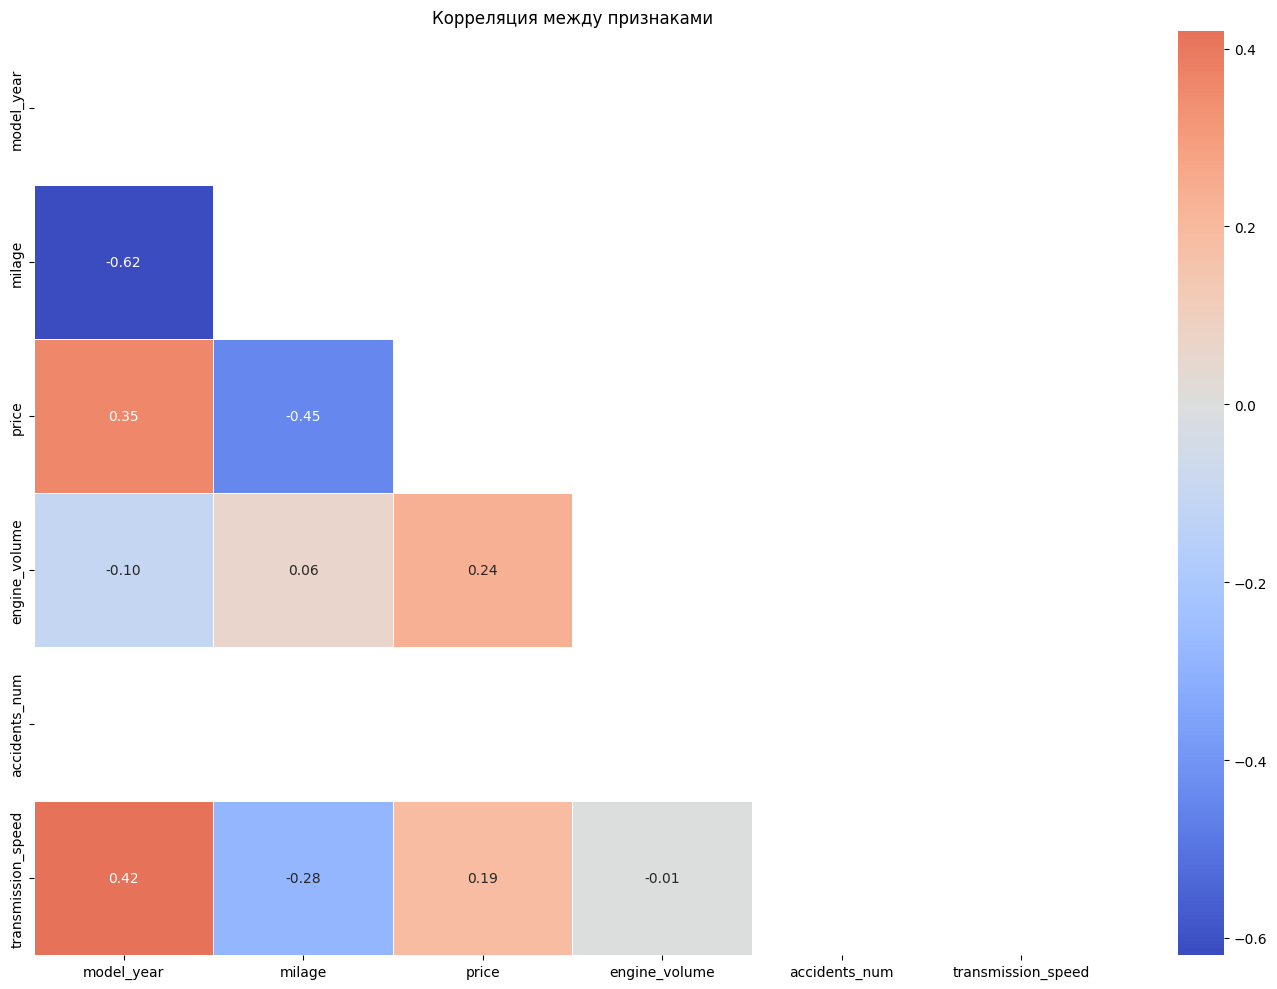

In [23]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

Видим, что все оставшиеся числовые признаки хорошо коррелируют с целевой переменной

# Применение моделей

Будем использовать линейную регрессию, рандомный лес, catboost для работы с категориальными признаками и попробуем XGboost

## Подготовка данных

применим one-hot-encoding для оставшихся категориальных признаков

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [25]:
df.isna().sum()

,0
brand,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
accident,113
clean_title,596
price,0
engine_volume,377


In [26]:
df =  df.drop(columns = ['accident', 'transmission', 'engine'])

In [27]:
feature_cols = ['brand', 'model_year', 'milage', 'fuel_type',
       'clean_title', 'engine_volume', 'accidents_num',
       'transmission_speed' ]
X_all = df[feature_cols].copy()

Y = df['price'].copy()


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_all, Y, test_size=0.2, random_state=42)

Теперь разберемся с нанами  
Для начала заполним их средними для числовых признаков и 'unknown' для категориальных

In [29]:
numeric_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(include='object').columns

X_train[numeric_cols] = X_train[numeric_cols].fillna(
    X_train[numeric_cols].mean()
)
X_test[numeric_cols] = X_test[numeric_cols].fillna(
    X_train[numeric_cols].mean()
)

X_train[cat_cols] = X_train[cat_cols].fillna('Unknown')
X_test[cat_cols] = X_test[cat_cols].fillna('Unknown')

In [30]:
X_train = pd.get_dummies(X_train)

In [31]:
X_test = pd.get_dummies(X_test)

In [32]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

# Линейная регрессия

Пронормируем данные для стабильной работы линейной регрессии

In [33]:
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

Теперь готовы обучать модель

## Метод наименьших квадратов

In [34]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

pd.DataFrame({
    'MSE': [mean_squared_error(y_test, y_pred_lr)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr))],
    'MAE': [mean_absolute_error(y_test, y_pred_lr)],
    'R²': [r2_score(y_test, y_pred_lr)],
}, index=['OLS'])

,MSE,RMSE,MAE,R²
OLS,8.403134e+08,28988.160117,15031.61406,0.68621


In [35]:
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 =  r2_score(y_test, y_pred_lr)
lr_mae =  mean_absolute_error(y_test, y_pred_lr)

## Ridge, Lasso, ElasticNet

In [36]:
models_reg = {
    'OLS': LinearRegression(),
    'Ridge (α=1)': Ridge(alpha=1),
    'Ridge (α=100)': Ridge(alpha=100),
    'Lasso (α=1)': Lasso(alpha=1),
    'Lasso (α=100)': Lasso(alpha=100),
    'ElasticNet': ElasticNet(alpha=1, l1_ratio=0.5),
}

results_reg = []
for name, model in models_reg.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results_reg.append({
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred),
    })

pd.DataFrame(results_reg).set_index('Model').round(2)

,RMSE,MAE,R²
Model,,,
OLS,28988.16,15031.61,0.69
Ridge (α=1),30043.13,15313.29,0.66
Ridge (α=100),41984.64,19365.18,0.34
Lasso (α=1),29009.58,15042.99,0.69
Lasso (α=100),31533.56,15685.20,0.63
ElasticNet,45029.90,19901.82,0.24


## Визуализация предсказаний

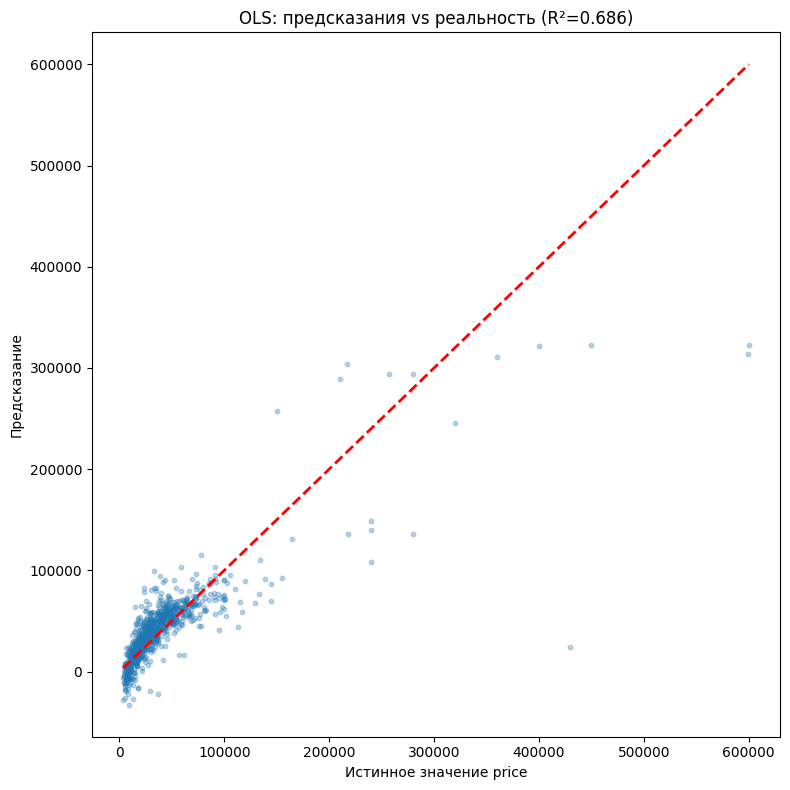

In [37]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_lr, alpha=0.3, s=10)
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', linewidth=2)
ax.set_xlabel('Истинное значение price')
ax.set_ylabel('Предсказание')
ax.set_title(f'OLS: предсказания vs реальность (R²={r2_score(y_test, y_pred_lr):.3f})')
plt.tight_layout()
plt.show()

# Случайный лес

Теперь применим RandomForest для регрессии

In [38]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import RandomizedSearchCV

In [39]:
model = RandomForestRegressor(random_state=42)


model = RandomForestRegressor(random_state=42)

params = {

    # количество деревьев
    'n_estimators': [
        100,
        200,
        300
    ],

    # максимальная глубина
    'max_depth': [
        None,
        10,
        20,
        30,
        50
    ],

    # минимальное количество объектов для split
    'min_samples_split': [
        2,
        5,
        10
    ],

    # минимальное количество объектов в листе
    'min_samples_leaf': [
        1,
        2,
        4
    ]
}


random_search = RandomizedSearchCV(
    estimator = model,
    param_distributions = params,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 50],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [41]:
print(random_search.best_params_)
print(-random_search.best_score_)
best_model = random_search.best_estimator_
preds = best_model.predict(X_test)


{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 30}
27286.540588894906


In [42]:
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import r2_score

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

mae = mean_absolute_error(y_test, preds)
print(mae)

print(rmse)

r2 = r2_score(y_test, preds)

print(r2)

10662.505262561615
29106.979048084024
0.683632293572004


In [43]:
rf_rmse = rmse
rf_r2 = r2
rf_mae = mae

In [44]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

importance.sort_values(ascending=False)

,0
milage,3.978555e-01
engine_volume,2.215211e-01
brand_Lamborghini,1.190076e-01
model_year,6.104553e-02
brand_Rolls-Royce,3.367722e-02
...,...
brand_Scion,1.367234e-06
brand_Mercury,6.450745e-07
brand_smart,5.976846e-07
brand_Saab,4.149702e-07


## Важность признаков

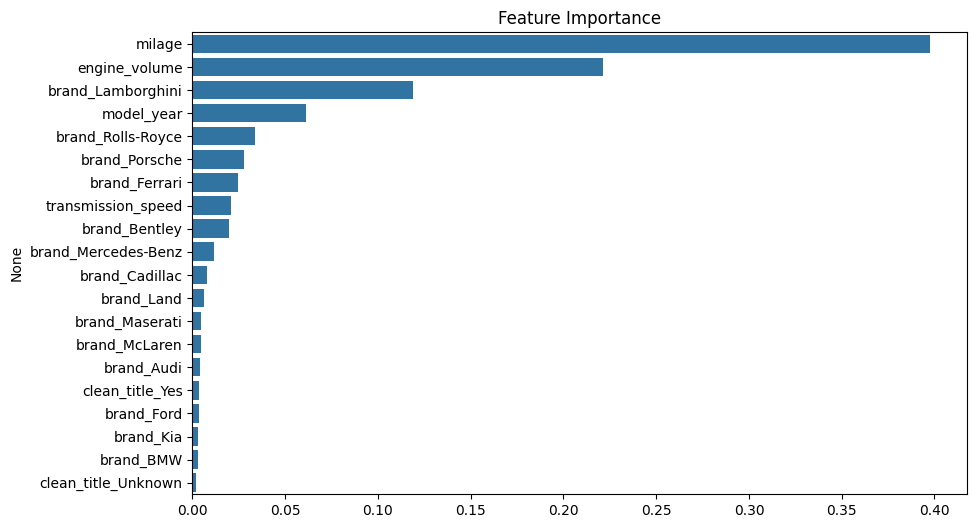

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(
    ascending=False
).head(20)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=importance.values,
    y=importance.index
)

plt.title('Feature Importance')

plt.show()

Как видим наиболее важными оказались пробег, год выпуска, объем двигателя и марка машины, дороже всех - ламборгини.

# Catboost

In [46]:
cat_features = X_all.select_dtypes(
    include = 'object'
).columns.tolist()

In [47]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_all, Y, test_size=0.2, random_state=42)

## Установка catboost

In [48]:
pip install catboost

## Обучение CatBoost

In [49]:
numeric_cols = X_train_cat.select_dtypes(include='number').columns
cat_cols = X_train_cat.select_dtypes(include='object').columns

X_train[numeric_cols] = X_train_cat[numeric_cols].fillna(
    X_train_cat[numeric_cols].mean()
)
X_test_cat[numeric_cols] = X_test_cat[numeric_cols].fillna(
    X_train_cat[numeric_cols].mean()
)

X_train_cat[cat_cols] = X_train_cat[cat_cols].fillna('Unknown')
X_test_cat[cat_cols] = X_test_cat[cat_cols].fillna('Unknown')

In [50]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    random_state=42,
    verbose=100
)

model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=cat_features
)

0:	learn: 49138.5044148	total: 53.4ms	remaining: 53.4s
100:	learn: 23958.2506416	total: 326ms	remaining: 2.9s
200:	learn: 21162.3672328	total: 562ms	remaining: 2.23s
300:	learn: 19226.6190669	total: 806ms	remaining: 1.87s
400:	learn: 17682.2826484	total: 1.07s	remaining: 1.59s
500:	learn: 16474.9273421	total: 1.34s	remaining: 1.34s
600:	learn: 15529.1614179	total: 1.6s	remaining: 1.06s
700:	learn: 14703.1734954	total: 1.85s	remaining: 790ms
800:	learn: 14001.5822097	total: 2.13s	remaining: 528ms
900:	learn: 13308.1150354	total: 2.39s	remaining: 263ms
999:	learn: 12717.7296523	total: 2.7s	remaining: 0us


CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=1000, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=100)

In [51]:
preds = model.predict(X_test_cat)

In [52]:
rmse = np.sqrt(
    mean_squared_error(y_test_cat, preds)
)

mae = mean_absolute_error(y_test_cat, preds)

r2 = r2_score(y_test_cat, preds)

print('RMSE:', rmse)
print('R²:', r2)

RMSE: 28945.14216389322
R²: 0.6871405673817328


In [53]:
cat_rmse = rmse
cat_r2 = r2
cat_mae = mae

In [54]:
importance = model.get_feature_importance()

importance = pd.Series(
    importance,
    index=X_train_cat.columns
).sort_values(ascending=False)

## Важность признаков

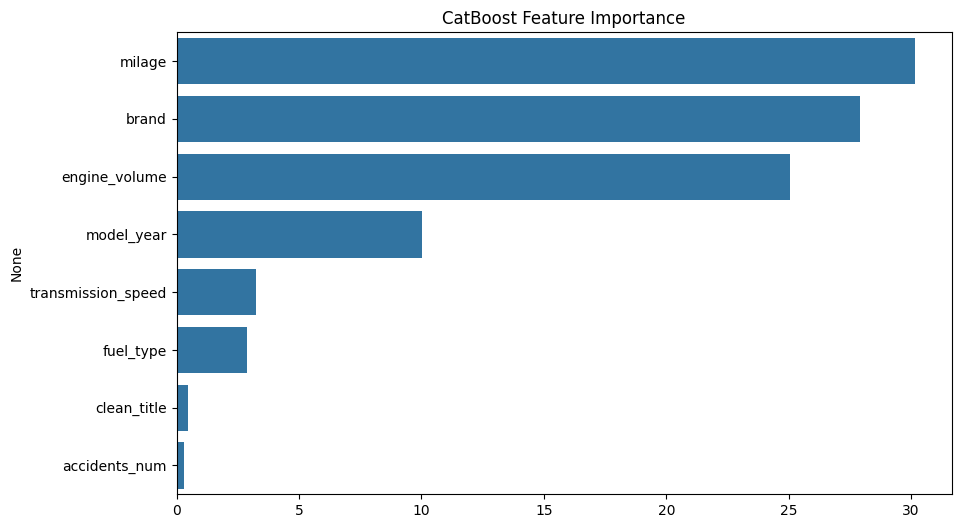

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x=importance.head(20).values,
    y=importance.head(20).index
)

plt.title('CatBoost Feature Importance')

plt.show()

# LightGBM

## Обучение модели

In [56]:
from lightgbm import LGBMRegressor
import lightgbm as lgb

X_train, X_test, y_train, y_test = train_test_split(X_all, Y, test_size=0.2, random_state=42)

numeric_cols = X_train_cat.select_dtypes(include='number').columns
cat_cols = X_train_cat.select_dtypes(include='object').columns

X_train[numeric_cols] = X_train_cat[numeric_cols].fillna(
    X_train_cat[numeric_cols].mean()
)
X_test_cat[numeric_cols] = X_test_cat[numeric_cols].fillna(
    X_train_cat[numeric_cols].mean()
)

X_train_cat[cat_cols] = X_train_cat[cat_cols].fillna('Unknown')
X_test_cat[cat_cols] = X_test_cat[cat_cols].fillna('Unknown')

cat_cols = X_train.select_dtypes(
    include='object'
).columns.tolist()

# переводим в category
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    eval_metric='rmse',
    max_depth=-1,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    categorical_feature=cat_cols,
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000440 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 409
[LightGBM] [Info] Number of data points in the train set: 3204, number of used features: 7
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Info] Start training from score 43269.082709
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l2: 1.10128e+09
[200]	valid_0's l2: 1.01774e+09
[300]	valid_0's l2: 9.93343e+08
[400]	valid_0's l2: 9.89588e+08
[500]	valid_0's l2: 9.95635e+08
Did not meet early stopping. Best iteration is:
[432]	valid_0's l2: 9.88507e+08


LGBMRegressor(colsample_bytree=0.8, eval_metric='rmse', learning_rate=0.05,
              n_estimators=500, random_state=42, subsample=0.8)

In [57]:
preds = model.predict(X_test)

[LightGBM] [Warning] Unknown parameter: eval_metric


In [58]:
rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

mae = mean_absolute_error(y_test, preds)

r2 = r2_score(y_test, preds)

print('RMSE:', rmse)
print('R²:', r2)

RMSE: 31440.523789727155
R²: 0.6308716301453919


In [59]:
lgb_rmse = rmse
lgb_r2 = r2
lgb_mae = mae

In [60]:
importance = model.booster_.feature_importance(
    importance_type='gain'
)

In [61]:
importance = pd.Series(
    importance,
    index=X_train.columns
).sort_values(ascending=False)

## Важность признаков

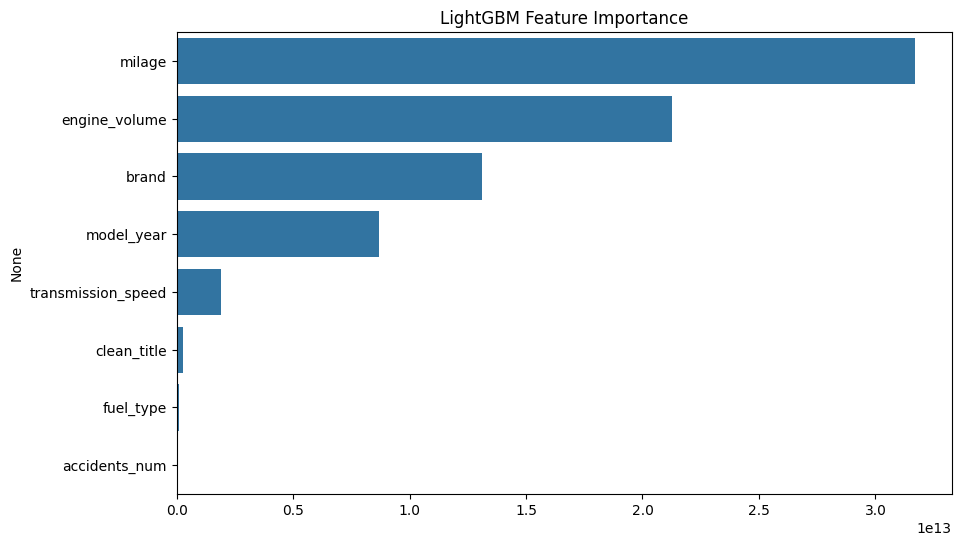

In [62]:
top_features = importance.head(20)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title('LightGBM Feature Importance')

plt.show()

# Дополнительное исследование

Также хотелось бы протестировать случайный лес, в котором мы удалим все строки, где встречаются значения nan

In [63]:
df = df.dropna()

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 458 entries, 0 to 3979
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   brand               458 non-null    object 
 1   model_year          458 non-null    int64  
 2   milage              458 non-null    float64
 3   fuel_type           458 non-null    object 
 4   clean_title         458 non-null    object 
 5   price               458 non-null    float64
 6   engine_volume       458 non-null    float64
 7   accidents_num       458 non-null    float64
 8   transmission_speed  458 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.8+ KB


In [65]:
X_all = df[feature_cols].copy()

Y = df['price'].copy()

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X_all, Y, test_size=0.2, random_state=42)

In [68]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [69]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [70]:
model = RandomForestRegressor(random_state=42)

params = {

    # количество деревьев
    'n_estimators': [
        50
    ],

    # максимальная глубина
    'max_depth': [
        None,
        10,
        20
    ],

    # минимальное количество объектов для split
    'min_samples_split': [
        2,
        5
    ],

    # минимальное количество объектов в листе
    'min_samples_leaf': [
        1,
        2,
        4
    ]
}


random_search = RandomizedSearchCV(
    estimator = model,
    param_distributions = params,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=30. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 18 candidates, totalling 90 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [50]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [71]:
print(random_search.best_params_)
print(-random_search.best_score_)
best_model = random_search.best_estimator_
preds = best_model.predict(X_test)

{'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}
10367.792843988711


In [72]:
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import r2_score

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

mae = mean_absolute_error(y_test, preds)
print(mae)

print(rmse)

r2 = r2_score(y_test, preds)

print(r2)

7851.947213559993
13268.06438409678
0.5070674318681792


# Результаты

In [73]:
results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Random Forest',
        'CatBoost',
        'LightGBM'
    ],

    'MAE': [
        lr_mae,
        rf_mae,
        cat_mae,
        lgb_mae
    ],

    'RMSE': [
        lr_rmse,
        rf_rmse,
        cat_rmse,
        lgb_rmse
    ],

    'R2': [
        lr_r2,
        rf_r2,
        cat_r2,
        lgb_r2
    ]

})

In [74]:
results = results.sort_values(
    'R2',
    ascending=False
)

## Оценка моделей

In [75]:
results

,Model,MAE,RMSE,R2
2,CatBoost,11381.211586,28945.142164,0.687141
0,Linear Regression,15031.614060,28988.160117,0.686210
1,Random Forest,10662.505263,29106.979048,0.683632
3,LightGBM,11784.264357,31440.523790,0.630872


## Выводы по гипотезам

По гипотезам:  
1.  Марка, пробег и двигатель действительно сильнее всего влияют на стоимость, однако немало важен оказались год выпуска и характеристики трансмиссии, в свою очередь история аварий мало влияла на цену
2.  Гипотеза оказалась верной наполовину. Цвет машины и салона действительно не влияет на ее стоимость, однако, как было сказано, трансмиссия вносит вклад в стоимость. Что касается вклада вида топлива, он небольшой, но, например, у catboost его значимость составляет около 3%, что не так уж и мало.
3.  Не совсем сбылась, линейная регрессия по показателям находится на втором месте после catboost, что говорит о нелинейных категориальных зависимостях, хоть и отклонение небольшое, но все же, оно есть
4.  Гипотеза не оправдалась, удалив все наны (примерно 3600 из 4000 признаков), мы заметно ухудшили качество модели, R^2 метрика равняется 50%, а с заменой нанов примерно 68%, то есть способность нашей модели адаптироваться к данным заметно ухудшилась  
  
Лучше всех справился catboost, хуже всех - LightGBM. Это можно объяснить тем, что он предзначначен для работы с большим объемом данных, наш же датасет содержит всего 4000 признаков, поэтому модель не успела обучиться, а если расширять глубину и другие гиперпараметры, существует огромный риск переобучиться.  
Вывод: Для подобных задач наиболее подходящими моделями оказались CatBoost и линейная регрессия